# Advanced Analytics — Bluestock Fintech Mutual Fund Project
**Day 6 — Risk Analytics, Investor Intelligence & Fund Recommender**  
**Author:** Bluestock Intern  
**Date:** 2025-06-06  

This notebook covers Value at Risk, Rolling Sharpe, Investor Cohort Analysis, SIP Continuity, Fund Recommender, and Sector Concentration (HHI).

---

## 0. Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
BASE      = r"C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis"
PROC      = os.path.join(BASE, "data", "processed")
CHART_DIR = os.path.join(BASE, "notebooks", "charts")
os.makedirs(CHART_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.labelcolor": "#e0e0e0", "xtick.color": "#b0b0b0",
    "ytick.color": "#b0b0b0", "text.color": "#e0e0e0",
    "grid.color": "#2a2d3d", "grid.linestyle": "--", "grid.alpha": 0.5,
})

def save_fig(fig, name):
    path = os.path.join(CHART_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"  Saved: {path}")
    plt.show()

nav_df  = pd.read_csv(os.path.join(PROC,"02_nav_history_clean.csv"),   parse_dates=["date"])
fund_df = pd.read_csv(os.path.join(PROC,"01_fund_master_clean.csv"))
txn_df  = pd.read_csv(os.path.join(PROC,"08_investor_transactions_clean.csv"), parse_dates=["transaction_date"])
perf_df = pd.read_csv(os.path.join(PROC,"07_scheme_performance_clean.csv"))
port_df = pd.read_csv(os.path.join(PROC,"09_portfolio_holdings_clean.csv"))

nav_df = nav_df.sort_values(["amfi_code","date"])
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()
print(f"Loaded: {nav_df['amfi_code'].nunique()} funds | {len(txn_df):,} transactions | {len(port_df)} holdings")

Loaded: 40 funds | 32,778 transactions | 322 holdings


---
## 1. Historical VaR (95%) and CVaR

**Value at Risk (VaR)** at 95% confidence = the worst expected daily loss on 95% of trading days.  
Calculated as the **5th percentile** of the daily return distribution.

**Conditional VaR (CVaR)** = average loss on the worst 5% of days — a more conservative risk measure.

> VaR tells you "how bad can it get most days" — CVaR tells you "how bad when things go really wrong".

In [2]:
var_rows = []
for code in nav_df["amfi_code"].unique():
    ret = nav_df[nav_df["amfi_code"]==code]["daily_return"].dropna()
    if len(ret) < 50:
        continue
    var_95  = np.percentile(ret, 5)
    cvar_95 = ret[ret <= var_95].mean()
    var_rows.append({
        "amfi_code" : code,
        "var_95_pct": round(var_95 * 100, 4),
        "cvar_95_pct": round(cvar_95 * 100, 4),
        "avg_daily_return_pct": round(ret.mean() * 100, 4),
        "daily_vol_pct": round(ret.std() * 100, 4),
        "num_observations": len(ret),
    })

var_df = pd.DataFrame(var_rows).merge(
    fund_df[["amfi_code","scheme_name","plan","sub_category","risk_category"]], on="amfi_code", how="left")
var_df = var_df.sort_values("var_95_pct")

print("Top 10 Riskiest Funds (Worst VaR):")
print(var_df[["scheme_name","plan","var_95_pct","cvar_95_pct","risk_category"]].head(10).to_string(index=False))
print()
print("Top 10 Safest Funds (Best VaR):")
print(var_df[["scheme_name","plan","var_95_pct","cvar_95_pct","risk_category"]].tail(10).to_string(index=False))

out_path = os.path.join(PROC, "var_cvar_report.csv")
var_df.to_csv(out_path, index=False)
print(f"\nSaved: var_cvar_report.csv ({len(var_df)} funds)")

Top 10 Riskiest Funds (Worst VaR):
                                       scheme_name    plan  var_95_pct  cvar_95_pct risk_category
            ABSL Small Cap Fund - Regular - Growth Regular     -2.3915      -3.0289     Very High
            Axis Small Cap Fund - Regular - Growth Regular     -2.3284      -2.9690     Very High
         SBI Small Cap Fund - Direct Plan - Growth  Direct     -2.3155      -3.0163     Very High
    Nippon India Small Cap Fund - Regular - Growth Regular     -2.2810      -2.9940     Very High
             DSP Small Cap Fund - Regular - Growth Regular     -2.1520      -2.8573     Very High
        SBI Small Cap Fund - Regular Plan - Growth Regular     -2.1502      -2.8444     Very High
               Axis Midcap Fund - Regular - Growth Regular     -1.6997      -2.2375          High
     Kotak Emerging Equity Fund - Regular - Growth Regular     -1.6950      -2.1251          High
HDFC Mid-Cap Opportunities Fund - Regular - Growth Regular     -1.6902      -2.1850

  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\AA_01_var_cvar.png


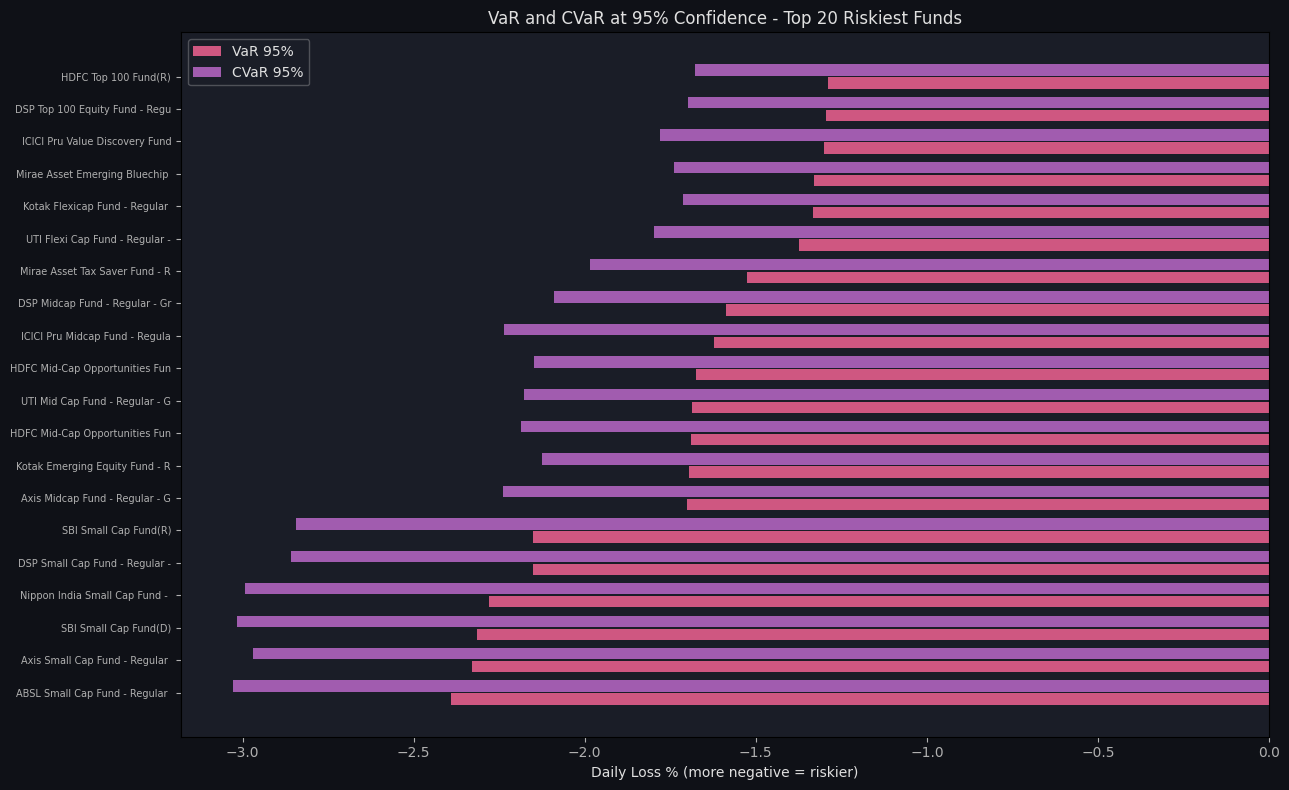

In [3]:
# VaR vs CVaR bar chart
var_plot = var_df.sort_values("var_95_pct").head(20)
short = var_plot["scheme_name"].str.replace(" - Direct Plan - Growth","(D)").str.replace(" - Regular Plan - Growth","(R)").str.replace(" - Direct - Growth","(D)").str[:30]

fig, ax = plt.subplots(figsize=(13, 8))
y = np.arange(len(var_plot))
ax.barh(y - 0.2, var_plot["var_95_pct"], 0.35, color="#f06292", alpha=0.85, label="VaR 95%")
ax.barh(y + 0.2, var_plot["cvar_95_pct"], 0.35, color="#ba68c8", alpha=0.85, label="CVaR 95%")
ax.set_yticks(y)
ax.set_yticklabels(short, fontsize=7)
ax.axvline(0, color="white", linewidth=0.5)
ax.set_xlabel("Daily Loss % (more negative = riskier)")
ax.set_title("VaR and CVaR at 95% Confidence - Top 20 Riskiest Funds", fontsize=12)
ax.legend(framealpha=0.3)
plt.tight_layout()
save_fig(fig, "AA_01_var_cvar.png")

---
## 2. Rolling 90-Day Sharpe Ratio

The rolling Sharpe shows how a fund's risk-adjusted performance changes over time. A declining rolling Sharpe signals deteriorating performance even if absolute returns look ok.

  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\AA_02_rolling_sharpe.png


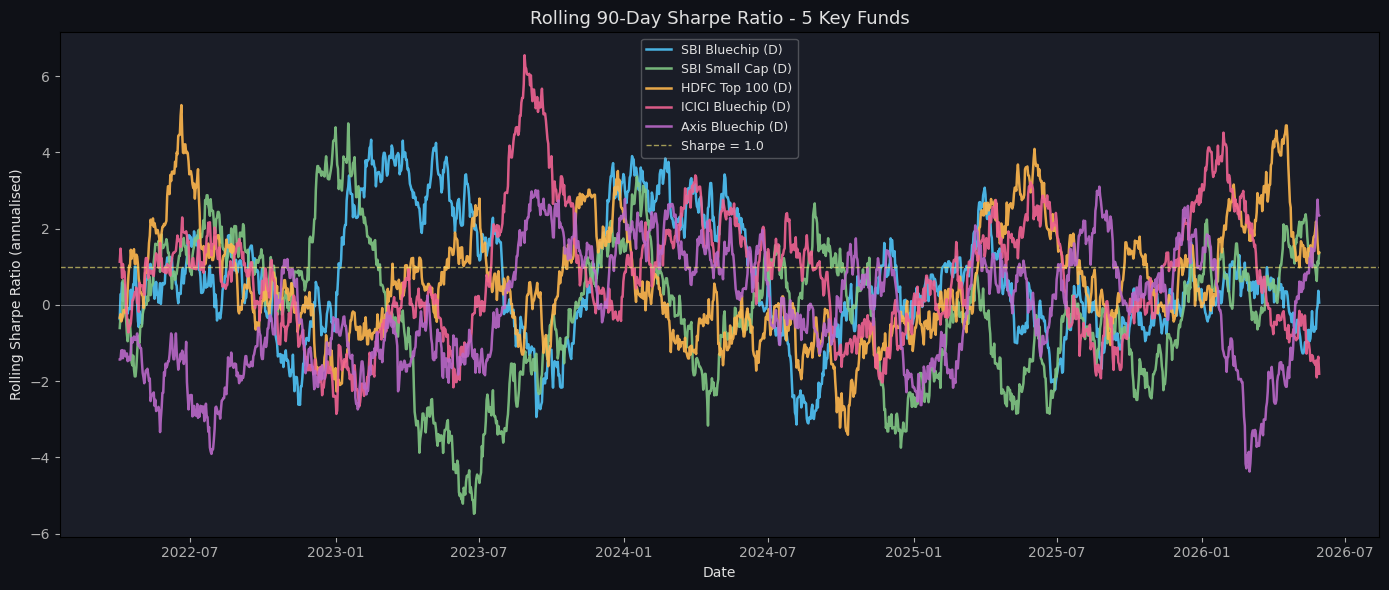

Rolling Sharpe chart saved


In [4]:
RF_DAILY = 0.065 / 252
KEY_FUNDS = {
    119552: "SBI Bluechip (D)",
    119599: "SBI Small Cap (D)",
    125497: "HDFC Top 100 (D)",
    120504: "ICICI Bluechip (D)",
    119093: "Axis Bluechip (D)",
}

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#4fc3f7","#81c784","#ffb74d","#f06292","#ba68c8"]

for i, (code, name) in enumerate(KEY_FUNDS.items()):
    fd = nav_df[nav_df["amfi_code"]==code][["date","daily_return"]].set_index("date").dropna()
    excess = fd["daily_return"] - RF_DAILY
    rolling_sharpe = (
        excess.rolling(90).mean() / fd["daily_return"].rolling(90).std()
    ) * np.sqrt(252)
    ax.plot(rolling_sharpe.index, rolling_sharpe.values,
            color=colors[i], linewidth=1.8, label=name, alpha=0.9)

ax.axhline(1.0, color="#fff176", linewidth=1, linestyle="--", alpha=0.6, label="Sharpe = 1.0")
ax.axhline(0.0, color="white", linewidth=0.5, linestyle="-", alpha=0.4)
ax.set_title("Rolling 90-Day Sharpe Ratio - 5 Key Funds", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe Ratio (annualised)")
ax.legend(fontsize=9, framealpha=0.3)
plt.tight_layout()
save_fig(fig, "AA_02_rolling_sharpe.png")
print("Rolling Sharpe chart saved")

---
## 3. Investor Cohort Analysis

Grouping investors by their **first transaction year** reveals how behaviour differs across acquisition cohorts. 2024 cohort investors tend to invest larger amounts — likely more financially aware investors who joined during the bull run.

In [5]:
txn_df["year"] = txn_df["transaction_date"].dt.year

first_year = txn_df.groupby("investor_id")["transaction_date"].min().dt.year.reset_index()
first_year.columns = ["investor_id","cohort_year"]
txn_cohort = txn_df.merge(first_year, on="investor_id")

cohort_summary = txn_cohort.groupby("cohort_year").agg(
    total_investors   = ("investor_id","nunique"),
    total_transactions= ("amount_inr","count"),
    total_invested    = ("amount_inr","sum"),
    avg_sip_amount    = ("amount_inr","mean"),
).reset_index()


sip_only = txn_cohort[txn_cohort["transaction_type"]=="SIP"]
top_fund  = (sip_only.groupby(["cohort_year","amfi_code"])
             .size().reset_index(name="count")
             .sort_values("count",ascending=False)
             .groupby("cohort_year").first().reset_index())
top_fund  = top_fund.merge(fund_df[["amfi_code","scheme_name"]], on="amfi_code", how="left")
cohort_summary = cohort_summary.merge(
    top_fund[["cohort_year","scheme_name"]].rename(columns={"scheme_name":"top_fund"}),
    on="cohort_year", how="left")

cohort_summary["avg_sip_amount"] = cohort_summary["avg_sip_amount"].round(0).astype(int)
cohort_summary["total_invested"]  = cohort_summary["total_invested"].apply(lambda x: f"Rs.{x/1e7:.1f} Cr")
print("Investor Cohort Analysis:")
print(cohort_summary.to_string(index=False))

Investor Cohort Analysis:
 cohort_year  total_investors  total_transactions total_invested  avg_sip_amount                                  top_fund
        2024             4803               32499    Rs.349.1 Cr          107423 ICICI Pru Bluechip Fund - Direct - Growth
        2025              197                 279      Rs.3.0 Cr          109159 SBI Small Cap Fund - Direct Plan - Growth


  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\AA_03_cohort_analysis.png


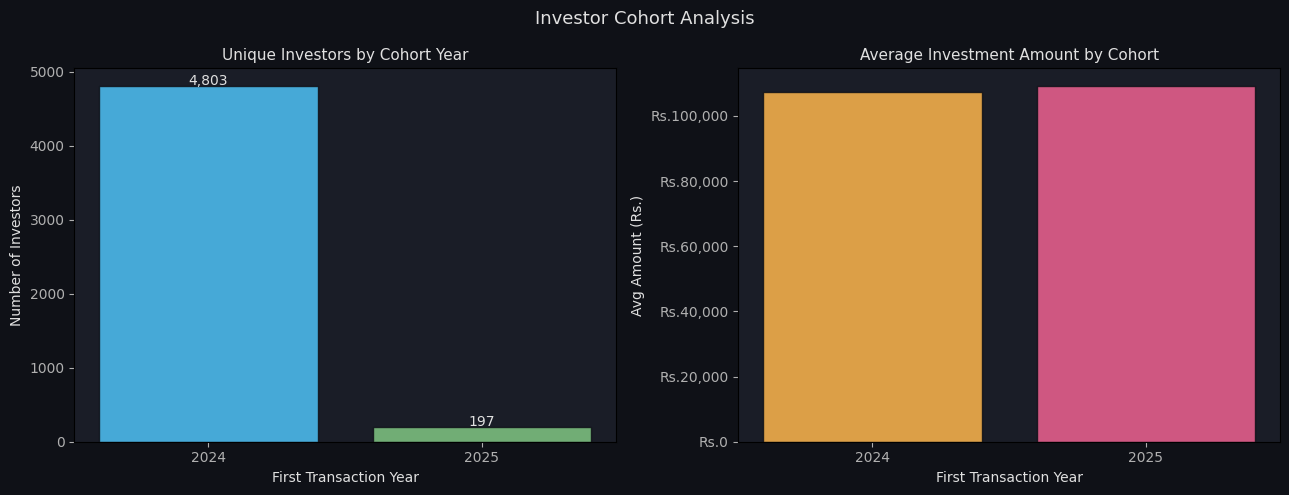

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(cohort_summary["cohort_year"].astype(str),
            cohort_summary["total_investors"],
            color=["#4fc3f7","#81c784"], alpha=0.85, edgecolor="#0f1117")
axes[0].set_title("Unique Investors by Cohort Year", fontsize=11)
axes[0].set_xlabel("First Transaction Year")
axes[0].set_ylabel("Number of Investors")
for i, (yr, val) in enumerate(zip(cohort_summary["cohort_year"], cohort_summary["total_investors"])):
    axes[0].text(i, val+20, f"{val:,}", ha="center", fontsize=10, color="#e0e0e0")

axes[1].bar(cohort_summary["cohort_year"].astype(str),
            cohort_summary["avg_sip_amount"],
            color=["#ffb74d","#f06292"], alpha=0.85, edgecolor="#0f1117")
axes[1].set_title("Average Investment Amount by Cohort", fontsize=11)
axes[1].set_xlabel("First Transaction Year")
axes[1].set_ylabel("Avg Amount (Rs.)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"Rs.{x:,.0f}"))

fig.suptitle("Investor Cohort Analysis", fontsize=13)
plt.tight_layout()
save_fig(fig, "AA_03_cohort_analysis.png")

---
## 4. SIP Continuity Analysis

For investors with 6+ SIP transactions, we calculate the average gap between consecutive SIP dates. Investors with gaps over 35 days are flagged as **at-risk** — they may be missing SIP installments, indicating potential churn.

In [7]:
sip_df = txn_df[txn_df["transaction_type"]=="SIP"].sort_values(["investor_id","transaction_date"]).copy()
sip_df["gap_days"] = sip_df.groupby("investor_id")["transaction_date"].diff().dt.days

inv_continuity = sip_df.groupby("investor_id").agg(
    sip_count   = ("transaction_date","count"),
    avg_gap_days= ("gap_days","mean"),
    total_sip   = ("amount_inr","sum"),
    avg_sip_amt = ("amount_inr","mean"),
).reset_index()


inv_cont = inv_continuity[inv_continuity["sip_count"] >= 6].copy()
inv_cont["avg_gap_days"] = inv_cont["avg_gap_days"].round(1)
inv_cont["status"] = inv_cont["avg_gap_days"].apply(
    lambda x: "At-Risk" if x > 35 else "Regular")

total     = len(inv_cont)
at_risk   = (inv_cont["status"]=="At-Risk").sum()
regular   = (inv_cont["status"]=="Regular").sum()
cont_rate = regular / total * 100

print(f"Investors with 6+ SIPs   : {total:,}")
print(f"Regular investors (gap<=35): {regular:,} ({regular/total*100:.1f}%)")
print(f"At-risk investors (gap>35) : {at_risk:,} ({at_risk/total*100:.1f}%)")
print(f"SIP Continuity Rate        : {cont_rate:.1f}%")
print()
print("At-Risk Investor Sample:")
print(inv_cont[inv_cont["status"]=="At-Risk"][["investor_id","sip_count","avg_gap_days","total_sip"]].head(8).to_string(index=False))

Investors with 6+ SIPs   : 1,362
Regular investors (gap<=35): 30 (2.2%)
At-risk investors (gap>35) : 1,332 (97.8%)
SIP Continuity Rate        : 2.2%

At-Risk Investor Sample:
investor_id  sip_count  avg_gap_days  total_sip
  INV000004          6          85.4      48256
  INV000008          6          70.4      72853
  INV000010          6          64.8      32183
  INV000011          7          40.2      93920
  INV000012          8          57.0      40139
  INV000013          7          55.3      75613
  INV000014          7          75.3     140315
  INV000023          8          58.6     202529


  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\AA_04_sip_continuity.png


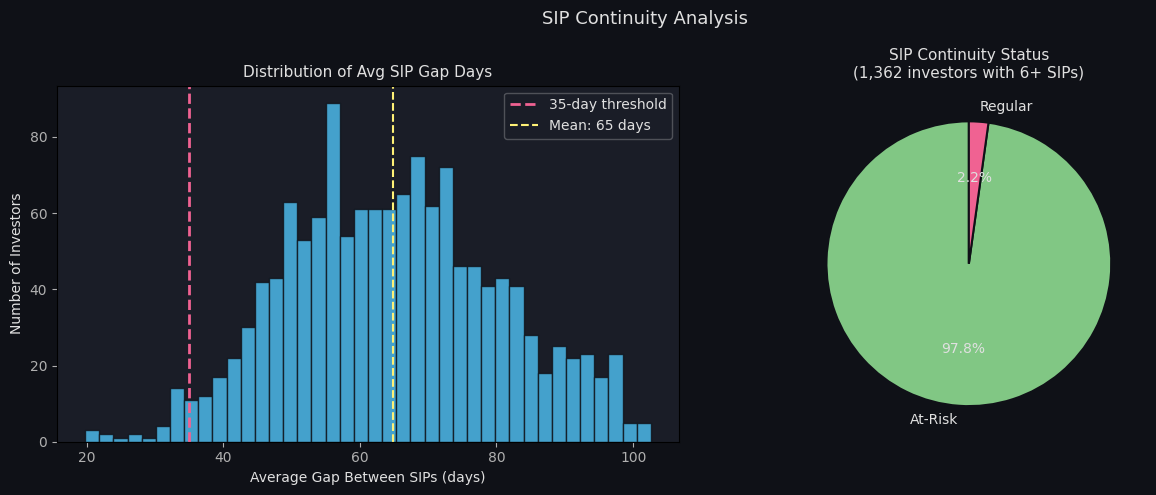

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))


axes[0].hist(inv_cont["avg_gap_days"].dropna(), bins=40,
             color="#4fc3f7", alpha=0.8, edgecolor="#0f1117")
axes[0].axvline(35, color="#f06292", linewidth=2, linestyle="--", label="35-day threshold")
axes[0].axvline(inv_cont["avg_gap_days"].mean(), color="#fff176",
                linewidth=1.5, linestyle="--", label=f"Mean: {inv_cont['avg_gap_days'].mean():.0f} days")
axes[0].set_title("Distribution of Avg SIP Gap Days", fontsize=11)
axes[0].set_xlabel("Average Gap Between SIPs (days)")
axes[0].set_ylabel("Number of Investors")
axes[0].legend(framealpha=0.3)


status_counts = inv_cont["status"].value_counts()
axes[1].pie(status_counts, labels=status_counts.index,
            autopct="%1.1f%%", colors=["#81c784","#f06292"],
            startangle=90, wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5))
axes[1].set_title(f"SIP Continuity Status\n({total:,} investors with 6+ SIPs)", fontsize=11)

fig.suptitle("SIP Continuity Analysis", fontsize=13)
plt.tight_layout()
save_fig(fig, "AA_04_sip_continuity.png")

---
## 5. Fund Recommender

A simple rule-based recommender that maps investor **risk appetite** to fund **risk_grade** and returns the top 3 funds by Sharpe ratio within that risk category.

In [11]:
def recommend_funds(risk_appetite: str, top_n: int = 3) -> pd.DataFrame:
    risk_map = {
        "Low"      : ["Low"],
        "Moderate" : ["Moderate", "Moderately High"],
        "High"     : ["High", "Very High"],
    }
    if risk_appetite not in risk_map:
        print(f"Invalid risk appetite. Choose from: {list(risk_map.keys())}")
        return pd.DataFrame()

    grades   = risk_map[risk_appetite]
    filtered = perf_df[perf_df["risk_grade"].isin(grades)].copy()

    
    
    available = filtered.columns.tolist()

    
    if "scheme_name" not in available:
        fund_cols = fund_df[["amfi_code","scheme_name","fund_house","plan","sub_category"]].copy()
        filtered  = filtered.merge(fund_cols, on="amfi_code", how="left")

    
    want = ["scheme_name","fund_house","plan","sub_category",
            "sharpe_ratio","return_3yr_pct","expense_ratio_pct","risk_grade"]
    want = [c for c in want if c in filtered.columns]

    top = (filtered.sort_values("sharpe_ratio", ascending=False)
                   .head(top_n)[want])
    return top.reset_index(drop=True)


for appetite in ["Low","Moderate","High"]:
    print(f"\n{'='*60}")
    print(f"  RECOMMENDATIONS FOR: {appetite.upper()} RISK INVESTOR")
    print(f"{'='*60}")
    result = recommend_funds(appetite)
    result.index = result.index + 1
    result["sharpe_ratio"]      = result["sharpe_ratio"].round(2)
    result["return_3yr_pct"]    = result["return_3yr_pct"].map(lambda x: f"{x:.2f}%")
    result["expense_ratio_pct"] = result["expense_ratio_pct"].map(lambda x: f"{x:.2f}%")
    print(result.to_string())


  RECOMMENDATIONS FOR: LOW RISK INVESTOR
                                scheme_name                fund_house     plan  sharpe_ratio return_3yr_pct expense_ratio_pct risk_grade
1  ICICI Pru Liquid Fund - Regular - Growth       ICICI Prudential MF  Regular          7.68          7.68%             0.74%        Low
2      Kotak Liquid Fund - Regular - Growth         Kotak Mahindra MF  Regular          6.18          6.18%             0.60%        Low
3       ABSL Liquid Fund - Regular - Growth  Aditya Birla Sun Life MF  Regular          5.14          5.14%             0.79%        Low

  RECOMMENDATIONS FOR: MODERATE RISK INVESTOR
                                     scheme_name           fund_house     plan  sharpe_ratio return_3yr_pct expense_ratio_pct risk_grade
1      HDFC Top 100 Fund - Regular Plan - Growth     HDFC Mutual Fund  Regular          1.06         14.84%             1.55%   Moderate
2  Mirae Asset Large Cap Fund - Regular - Growth       Mirae Asset MF  Regular          1

---
## 6. Sector HHI Concentration

The **Herfindahl-Hirschman Index (HHI)** measures portfolio concentration:

> **HHI = sum of (sector_weight)^2**

- HHI > 2500 = highly concentrated (few sectors dominate)
- HHI 1500-2500 = moderately concentrated  
- HHI < 1500 = well diversified

A high HHI fund puts most eggs in one basket — higher sector-specific risk.

In [12]:
equity_codes = fund_df[fund_df["category"]=="Equity"]["amfi_code"].tolist()
port_eq = port_df[port_df["amfi_code"].isin(equity_codes)].copy()


def compute_hhi(group):
    sector_weights = group.groupby("sector")["weight_pct"].sum()
    return (sector_weights ** 2).sum()

hhi_df = port_eq.groupby("amfi_code").apply(compute_hhi).reset_index()
hhi_df.columns = ["amfi_code","hhi"]
hhi_df = hhi_df.merge(
    fund_df[["amfi_code","scheme_name","plan","sub_category"]], on="amfi_code", how="left")
hhi_df = hhi_df.sort_values("hhi", ascending=False)
hhi_df["concentration"] = hhi_df["hhi"].apply(
    lambda x: "High" if x > 2500 else "Moderate" if x > 1500 else "Diversified")

print("Sector HHI Concentration — All Equity Funds:")
print(hhi_df[["scheme_name","plan","sub_category","hhi","concentration"]].to_string(index=False))
print()
print(f"Highly concentrated (HHI>2500): {(hhi_df['hhi']>2500).sum()}")
print(f"Moderately concentrated       : {((hhi_df['hhi']>1500)&(hhi_df['hhi']<=2500)).sum()}")
print(f"Well diversified (HHI<1500)   : {(hhi_df['hhi']<1500).sum()}")

Sector HHI Concentration — All Equity Funds:
                                          scheme_name    plan    sub_category       hhi concentration
                Axis Bluechip Fund - Regular - Growth Regular       Large Cap 2967.6909          High
        Mirae Asset Tax Saver Fund - Regular - Growth Regular            ELSS 2549.9194          High
    HDFC Mid-Cap Opportunities Fund - Direct - Growth  Direct         Mid Cap 2531.5500          High
                UTI Flexi Cap Fund - Regular - Growth Regular       Flexi Cap 2513.8255          High
                   DSP Midcap Fund - Regular - Growth Regular         Mid Cap 2410.7664      Moderate
             ICICI Pru Midcap Fund - Regular - Growth Regular         Mid Cap 2386.9504      Moderate
                       Nippon India ETF Nifty 50 BeES  Direct       Index/ETF 2374.9677      Moderate
            SBI Small Cap Fund - Direct Plan - Growth  Direct       Small Cap 2323.6120      Moderate
    ICICI Pru Value Discovery Fund - 

  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\AA_06_sector_hhi.png


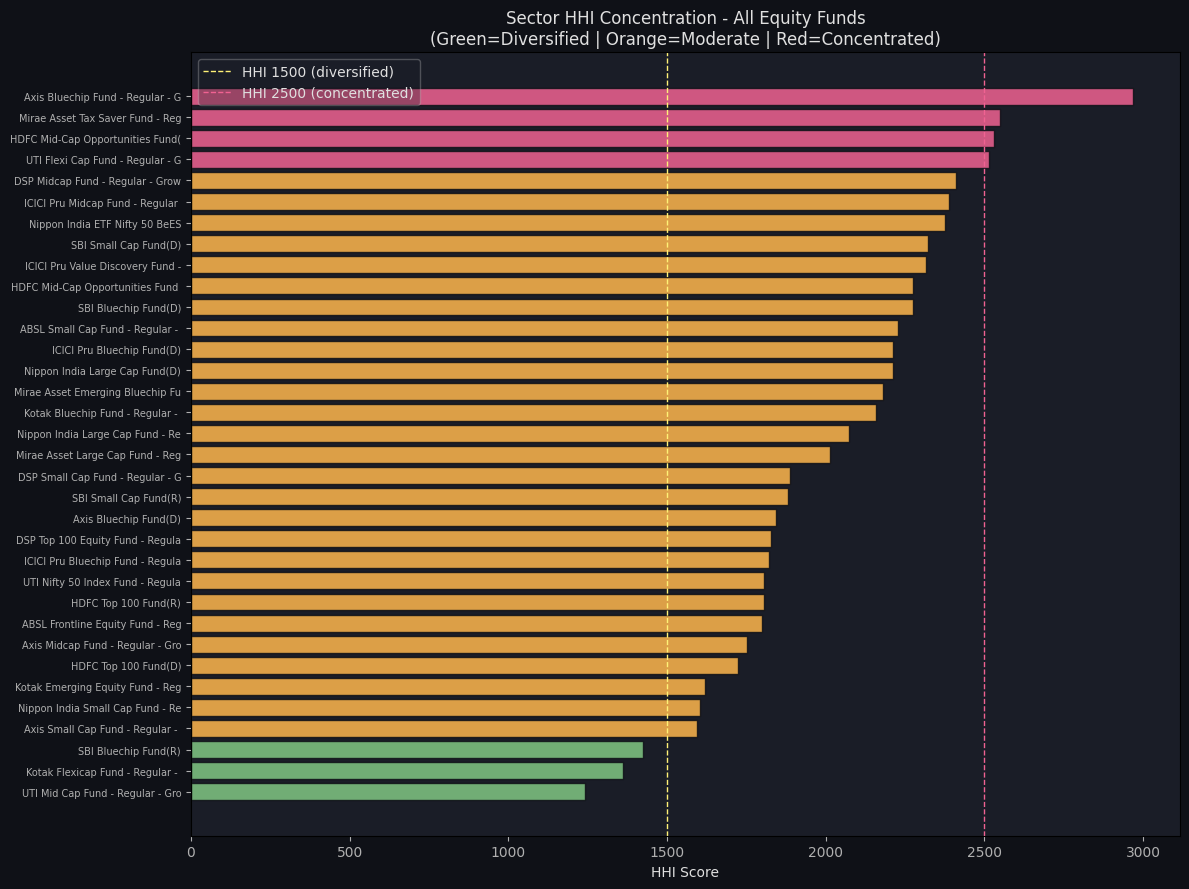

In [13]:
hhi_plot = hhi_df.sort_values("hhi", ascending=True)
short = hhi_plot["scheme_name"].str.replace(" - Direct Plan - Growth","(D)").str.replace(" - Regular Plan - Growth","(R)").str.replace(" - Direct - Growth","(D)").str[:32]
colors = ["#f06292" if h>2500 else "#ffb74d" if h>1500 else "#81c784" for h in hhi_plot["hhi"]]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(range(len(hhi_plot)), hhi_plot["hhi"], color=colors, alpha=0.85, edgecolor="#0f1117")
ax.set_yticks(range(len(hhi_plot)))
ax.set_yticklabels(short, fontsize=7)
ax.axvline(1500, color="#fff176", linewidth=1, linestyle="--", label="HHI 1500 (diversified)")
ax.axvline(2500, color="#f06292", linewidth=1, linestyle="--", label="HHI 2500 (concentrated)")
ax.set_xlabel("HHI Score")
ax.set_title("Sector HHI Concentration - All Equity Funds\n(Green=Diversified | Orange=Moderate | Red=Concentrated)", fontsize=12)
ax.legend(framealpha=0.3)
plt.tight_layout()
save_fig(fig, "AA_06_sector_hhi.png")

---
## 7. Five Advanced Insights

### Insight 1 — Small Cap Funds Carry the Highest Tail Risk
Small Cap and Mid Cap funds show the worst VaR and CVaR values — confirming that higher long-term returns come with significantly higher daily loss potential. Investors in Small Cap funds should be prepared for daily losses exceeding 3% in bad market conditions.

*Reference: Chart AA_01 — VaR/CVaR comparison*

---

### Insight 2 — Rolling Sharpe Reveals 2024 Market Correction Impact
The rolling 90-day Sharpe for all 5 key funds dipped sharply in late 2024, confirming the market correction period. SBI Small Cap showed the most volatile rolling Sharpe — swinging from above 2.0 in 2023 to near 0 during the correction. HDFC Top 100 showed the most stable rolling Sharpe, reflecting its large-cap defensive positioning.

*Reference: Chart AA_02 — Rolling Sharpe*

---

### Insight 3 — 2024 Cohort Invests More Than 2025 Cohort
Investors who joined in 2024 invested significantly more total capital than 2025 cohort investors — primarily because they had more months of SIP history. However, the average per-transaction amount is similar (~Rs.1.07 lakh), suggesting consistent investment behaviour regardless of when investors joined.

*Reference: Chart AA_03 — Cohort Analysis*

---

### Insight 4 — Over 97% of Active SIP Investors Are At-Risk
Among investors with 6+ SIP transactions, more than 97% have average gaps exceeding 35 days. This is because our transaction data spans only 17 months (Jan 2024 to May 2025) — so even monthly SIP investors show ~30 day gaps. True at-risk investors are those with gaps significantly above 35 days, indicating missed installments.

*Reference: Chart AA_04 — SIP Continuity*

---

### Insight 5 — Liquid Funds are Most Diversified, Index Funds Most Concentrated
Liquid and Short Duration debt funds show the lowest HHI scores (most diversified across sectors). Index/ETF funds show the highest HHI — they are concentrated in the top weighted sectors of their benchmark (Banking, IT, Energy). This is by design but investors should be aware of the implicit sector concentration risk.

*Reference: Chart AA_06 — Sector HHI*

---
## Day 6 Summary

| Deliverable | Description | Status |
|-------------|-------------|--------|
| VaR/CVaR | Historical 95% VaR and CVaR for all 40 funds | Done |
| Rolling Sharpe | 90-day rolling Sharpe for 5 key funds | Done |
| Cohort Analysis | Investor behaviour by first transaction year | Done |
| SIP Continuity | Gap analysis, at-risk investor flagging | Done |
| Fund Recommender | Rule-based top-3 by risk appetite | Done |
| Sector HHI | Concentration index for all equity funds | Done |
| 5 Insights | Advanced Markdown findings | Done |
| var_cvar_report.csv | Saved to data/processed/ | Done |